# Khám phá chu kỳ trong exon và intron bằng Hidden Markov Model

**Notebook tái hiện phương pháp trong mục “Discovering Periodic Patterns in Exons and Introns by Means of New HMM Architectures”.**

Notebook này thực hiện trọn pipeline:

1. Phát biểu bài toán sinh học và mô hình xác suất.
2. Chuẩn bị dữ liệu theo hai chế độ:
   - **Demo chạy ngay:** dữ liệu mô phỏng có chu kỳ 10 nucleotide.
   - **Dữ liệu thật:** trích internal exon và deep intron từ GENCODE/GRCh38.
3. Xây dựng baseline IID và Markov bậc 1.
4. Cài đặt **tied periodic HMM** bằng EM.
5. Quét chu kỳ ứng viên từ 3 đến 15.
6. So sánh exon, intron và dữ liệu shuffle bảo toàn nucleotide composition.
7. Cài đặt **flexible wheel HMM** với các chuyển tiếp stay/advance/skip.
8. Đánh giá bằng held-out negative log-likelihood trên mỗi nucleotide, bootstrap và kiểm tra nhiều control.
9. Trực quan hóa emission distribution, entropy và consensus motif.

> **Phạm vi tái lập:** tập 2.019 exon, accession ID, random seed và split chính xác của nghiên cứu năm 1995 không được công bố đầy đủ. Vì vậy notebook tái lập **phương pháp và logic thí nghiệm**, không cam kết tái tạo đúng từng con số của sách.

## 1. Bối cảnh bài toán

Tài liệu mô tả các quan sát chính:

- Standard HMM được huấn luyện trên 500 internal exon dài 100–200 nt, có 100 nt intron ở mỗi phía.
- Emission probabilities cho thấy một mẫu dao động khoảng 10 nt; đồng thời có tín hiệu yếu khoảng 3 nt liên quan reading frame.
- Tied model hard-code chu kỳ 10 bằng cách chia sẻ tham số giữa các đoạn lặp.
- Loop/wheel HMM cho phép chuỗi đi vào vòng tại nhiều pha và lặp số lần linh hoạt.
- Các wheel có số trạng thái khác nhau được so sánh bằng negative log-likelihood để xác định chu kỳ phù hợp nhất.

### Câu hỏi thực nghiệm

1. Exon có likelihood tốt hơn dưới mô hình tuần hoàn so với mô hình không tuần hoàn không?
2. Chu kỳ phù hợp nhất có gần 10 nt không?
3. Tín hiệu có còn tồn tại sau khi shuffle nucleotide trong từng chuỗi không?
4. Tín hiệu exon có mạnh hơn deep intron không?
5. Kết quả có phải chỉ do chu kỳ codon 3 nt không?

## 2. HMM tuần hoàn được dùng trong notebook

### 2.1. Tied periodic HMM

Giả sử chu kỳ ứng viên là $K$. Hidden state là pha trong chu kỳ:

$$Z_t \in \{0,1,\ldots,K-1\}.$$

Mỗi chuỗi có một pha bắt đầu ẩn $S$ và sau đó tiến đều:

$$Z_t=(S+t)\bmod K.$$

Emission distribution tại pha $k$ là:

$$B_{k,b}=P(X_t=b\mid Z_t=k),\qquad b\in\{A,C,G,T\}.$$

Likelihood của chuỗi khi bắt đầu ở pha $s$:

$$P(x\mid S=s)=\prod_{t=0}^{T-1} B_{(s+t)\bmod K,x_t}.$$

Pha bắt đầu không quan sát được, nên:

$$P(x)=\sum_{s=0}^{K-1}\pi_sP(x\mid S=s).$$

EM chỉ cần suy luận posterior của $S$. Đây là một HMM vòng với transition xác định từ pha $k$ sang $(k+1)\bmod K$.

### 2.2. Flexible wheel HMM

Để mô phỏng insert/delete hoặc sai lệch pha, ta cho phép ba loại cạnh:

- `stay`: $k\rightarrow k$;
- `advance`: $k\rightarrow (k+1)\bmod K$;
- `skip`: $k\rightarrow (k+2)\bmod K$.

Forward–backward/Baum–Welch được dùng để học cả transition và emission probabilities.

## 3. Cài đặt và cấu hình

Các thư viện chính: `numpy`, `pandas`, `scipy`, `matplotlib`. Chế độ dữ liệu thật cần thêm `pyfaidx` để đọc ngẫu nhiên từ genome FASTA.

In [1]:
from __future__ import annotations

from collections import Counter, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence
import gzip
import math
import re
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp

SEED = 42
RNG = np.random.default_rng(SEED)

ALPHABET = np.array(list("ACGT"))
ENCODE = {base: i for i, base in enumerate(ALPHABET)}
DECODE = {i: base for base, i in ENCODE.items()}

OUTPUT_DIR = Path("outputs_hmm_periodicity")
OUTPUT_DIR.mkdir(exist_ok=True)

# Mặc định dùng dữ liệu mô phỏng để notebook chạy ngay.
USE_REAL_DATA = False
DOWNLOAD_GENCODE = False

# Cấu hình thí nghiệm gần với bài toán trong sách.
MIN_EXON_LEN = 100
MAX_EXON_LEN = 200
FLANK = 100
DEEP_INTRON_MARGIN = 400

print("NumPy:", np.__version__)
print("Output directory:", OUTPUT_DIR.resolve())

NumPy: 2.3.5
Output directory: /mnt/data/outputs_hmm_periodicity


## 4. Nguồn dữ liệu thật: GENCODE 50 / GRCh38

GENCODE 50 là release hiện hành tại thời điểm tạo notebook. Hai file cần dùng:

- `gencode.v50.annotation.gtf.gz`: annotation gene/transcript/exon.
- `GRCh38.primary_assembly.genome.fa.gz`: genome sequence.

Genome FASTA có dung lượng lớn. Cell tải dữ liệu bị tắt mặc định để tránh tải ngoài ý muốn.

Khi dùng dữ liệu thật:

1. đặt `DOWNLOAD_GENCODE = True` để tải một lần, hoặc tự đặt file vào `data/gencode50/`;
2. giải nén hai file;
3. cài `pyfaidx`: `%pip install pyfaidx`;
4. đặt `USE_REAL_DATA = True`;
5. chạy lại notebook từ đầu.

In [2]:
GENCODE_DIR = Path("data/gencode50")
GENCODE_DIR.mkdir(parents=True, exist_ok=True)

GTF_GZ = GENCODE_DIR / "gencode.v50.annotation.gtf.gz"
FASTA_GZ = GENCODE_DIR / "GRCh38.primary_assembly.genome.fa.gz"
GTF_PATH = GENCODE_DIR / "gencode.v50.annotation.gtf"
FASTA_PATH = GENCODE_DIR / "GRCh38.primary_assembly.genome.fa"

GENCODE_URLS = {
    GTF_GZ: "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_50/gencode.v50.annotation.gtf.gz",
    FASTA_GZ: "https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_50/GRCh38.primary_assembly.genome.fa.gz",
}


def download_with_progress(url: str, destination: Path) -> None:
    """Download a file only when explicitly requested."""
    destination.parent.mkdir(parents=True, exist_ok=True)
    if destination.exists():
        print(f"Đã tồn tại: {destination}")
        return
    print(f"Đang tải {url}")
    urllib.request.urlretrieve(url, destination)
    print(f"Đã lưu: {destination}")


def gunzip_file(source: Path, destination: Path) -> None:
    if destination.exists():
        print(f"Đã tồn tại: {destination}")
        return
    with gzip.open(source, "rb") as src, destination.open("wb") as dst:
        while True:
            block = src.read(1024 * 1024)
            if not block:
                break
            dst.write(block)
    print(f"Đã giải nén: {destination}")


if DOWNLOAD_GENCODE:
    for destination, url in GENCODE_URLS.items():
        download_with_progress(url, destination)
    gunzip_file(GTF_GZ, GTF_PATH)
    gunzip_file(FASTA_GZ, FASTA_PATH)
else:
    print("Bỏ qua tải GENCODE. Đặt DOWNLOAD_GENCODE=True khi thực sự cần dữ liệu thật.")

Bỏ qua tải GENCODE. Đặt DOWNLOAD_GENCODE=True khi thực sự cần dữ liệu thật.


## 5. Hàm xử lý chuỗi và tạo dữ liệu demo

Dữ liệu mô phỏng có chủ đích:

- exon chứa chu kỳ 10 nt;
- một đoạn ba vị trí có consensus gần `[^T][AT]G`;
- chiều dài exon nằm trong 100–200 nt;
- intron có nucleotide composition gần exon nhưng không có cấu trúc theo pha;
- mỗi exon có pha bắt đầu ngẫu nhiên, nên không thể phát hiện bằng cách căn thẳng tất cả chuỗi theo vị trí 0.

Đây là sanity check: pipeline đúng phải chọn $K=10$ trên exon, nhưng không chọn rõ $K=10$ trên intron hoặc shuffled exon.

In [3]:
def clean_sequence(sequence: str) -> str:
    sequence = sequence.upper().replace("U", "T")
    return "".join(base for base in sequence if base in ENCODE)


def encode_sequence(sequence: str) -> np.ndarray:
    sequence = clean_sequence(sequence)
    return np.fromiter((ENCODE[b] for b in sequence), dtype=np.int8)


def decode_sequence(sequence: np.ndarray) -> str:
    return "".join(DECODE[int(x)] for x in sequence)


def reverse_complement(sequence: str) -> str:
    table = str.maketrans("ACGTNacgtn", "TGCANtgcan")
    return sequence.translate(table)[::-1]


def build_periodic_profile(period: int = 10) -> np.ndarray:
    """Create an emission profile with a 10-nt oscillation and [^T][AT]G motif."""
    background = np.array([0.28, 0.22, 0.22, 0.28], dtype=float)
    profile = np.tile(background, (period, 1))

    # Smooth purine/pyrimidine phase pattern.
    for phase in range(period):
        wave = np.cos(2 * np.pi * phase / period)
        profile[phase] += 0.06 * wave * np.array([1.0, -1.0, 1.0, -1.0])
        profile[phase] = np.clip(profile[phase], 0.02, None)
        profile[phase] /= profile[phase].sum()

    # Make a visible [^T][AT]G-like motif at phases 2, 3, 4.
    if period >= 5:
        profile[2] = [0.36, 0.28, 0.30, 0.06]
        profile[3] = [0.46, 0.05, 0.05, 0.44]
        profile[4] = [0.04, 0.05, 0.87, 0.04]
    return profile


def sample_periodic_sequences(
    n_sequences: int,
    period: int = 10,
    min_length: int = 100,
    max_length: int = 200,
    seed: int = 42,
) -> tuple[list[np.ndarray], np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    profile = build_periodic_profile(period)
    sequences, start_phases = [], []

    for _ in range(n_sequences):
        length = int(rng.integers(min_length, max_length + 1))
        start_phase = int(rng.integers(period))
        sequence = np.empty(length, dtype=np.int8)
        for position in range(length):
            phase = (start_phase + position) % period
            sequence[position] = rng.choice(4, p=profile[phase])
        sequences.append(sequence)
        start_phases.append(start_phase)

    return sequences, np.asarray(start_phases), profile


def sample_iid_sequences(
    n_sequences: int,
    composition: np.ndarray,
    min_length: int = 100,
    max_length: int = 200,
    seed: int = 43,
) -> list[np.ndarray]:
    rng = np.random.default_rng(seed)
    sequences = []
    for _ in range(n_sequences):
        length = int(rng.integers(min_length, max_length + 1))
        sequences.append(rng.choice(4, size=length, p=composition).astype(np.int8))
    return sequences


def shuffle_within_sequences(sequences: Sequence[np.ndarray], seed: int = 44) -> list[np.ndarray]:
    """Preserve length and nucleotide composition of every individual sequence."""
    rng = np.random.default_rng(seed)
    return [rng.permutation(sequence).astype(np.int8) for sequence in sequences]


def nucleotide_composition(sequences: Sequence[np.ndarray]) -> np.ndarray:
    counts = np.bincount(np.concatenate(sequences), minlength=4).astype(float)
    return counts / counts.sum()


def make_metadata(sequences: Sequence[np.ndarray], label: str) -> pd.DataFrame:
    return pd.DataFrame({
        "sample_id": [f"{label}_{i:04d}" for i in range(len(sequences))],
        "gene_id": [f"synthetic_gene_{i:04d}" for i in range(len(sequences))],
        "label": label,
        "length": [len(x) for x in sequences],
    })

## 6. Trích internal exon và deep intron từ GTF + genome FASTA

Cell dưới đây được định nghĩa để dùng khi `USE_REAL_DATA=True`.

### Quy tắc lọc

- `gene_type == protein_coding`;
- `transcript_type == protein_coding`;
- chọn một transcript đại diện cho mỗi gene, ưu tiên `MANE_Select`, sau đó `Ensembl_canonical`, sau đó transcript có tổng chiều dài exon lớn nhất;
- chỉ giữ internal exon, tức bỏ exon đầu và cuối theo chiều phiên mã;
- chiều dài exon 100–200 nt;
- hai intron lân cận phải đủ dài để lấy 100 nt flank;
- reverse-complement gene nằm trên strand âm;
- deep intron được lấy sau khi bỏ 400 nt ở mỗi đầu splice site.

Khi đánh giá nghiêm túc, cần split theo gene hoặc chromosome, không split ngẫu nhiên từng exon.

In [4]:
ATTRIBUTE_PATTERN = re.compile(r'(\S+)\s+"([^"]+)"')


def parse_gtf_attributes(attribute_text: str) -> dict[str, list[str]]:
    attributes: dict[str, list[str]] = defaultdict(list)
    for key, value in ATTRIBUTE_PATTERN.findall(attribute_text):
        attributes[key].append(value)
    return dict(attributes)


def first_attribute(attributes: dict[str, list[str]], *keys: str, default: str = "") -> str:
    for key in keys:
        values = attributes.get(key)
        if values:
            return values[0]
    return default


@dataclass
class ExonRecord:
    chrom: str
    start: int       # 1-based inclusive
    end: int         # 1-based inclusive
    strand: str
    gene_id: str
    transcript_id: str
    tags: tuple[str, ...]


@dataclass
class TranscriptRecord:
    chrom: str
    strand: str
    gene_id: str
    transcript_id: str
    tags: set[str]
    exons: list[ExonRecord]


def load_protein_coding_transcripts(gtf_path: Path) -> dict[str, TranscriptRecord]:
    transcripts: dict[str, TranscriptRecord] = {}
    opener = gzip.open if str(gtf_path).endswith(".gz") else open

    with opener(gtf_path, "rt") as handle:
        for line in handle:
            if line.startswith("#"):
                continue
            fields = line.rstrip("\n").split("\t")
            if len(fields) != 9 or fields[2] != "exon":
                continue

            chrom, _, _, start, end, _, strand, _, attribute_text = fields
            attributes = parse_gtf_attributes(attribute_text)
            gene_type = first_attribute(attributes, "gene_type", "gene_biotype")
            transcript_type = first_attribute(attributes, "transcript_type", "transcript_biotype")
            if gene_type != "protein_coding" or transcript_type != "protein_coding":
                continue

            gene_id = first_attribute(attributes, "gene_id")
            transcript_id = first_attribute(attributes, "transcript_id")
            tags = tuple(attributes.get("tag", []))
            if not gene_id or not transcript_id:
                continue

            exon = ExonRecord(
                chrom=chrom,
                start=int(start),
                end=int(end),
                strand=strand,
                gene_id=gene_id,
                transcript_id=transcript_id,
                tags=tags,
            )
            if transcript_id not in transcripts:
                transcripts[transcript_id] = TranscriptRecord(
                    chrom=chrom,
                    strand=strand,
                    gene_id=gene_id,
                    transcript_id=transcript_id,
                    tags=set(tags),
                    exons=[],
                )
            transcripts[transcript_id].exons.append(exon)
            transcripts[transcript_id].tags.update(tags)

    return transcripts


def select_representative_transcripts(
    transcripts: dict[str, TranscriptRecord],
) -> list[TranscriptRecord]:
    by_gene: dict[str, list[TranscriptRecord]] = defaultdict(list)
    for transcript in transcripts.values():
        if len(transcript.exons) >= 3:
            by_gene[transcript.gene_id].append(transcript)

    selected = []
    for gene_id, candidates in by_gene.items():
        def score(tx: TranscriptRecord) -> tuple[int, int]:
            priority = 0
            if "MANE_Select" in tx.tags:
                priority = 3
            elif "Ensembl_canonical" in tx.tags:
                priority = 2
            elif "basic" in tx.tags:
                priority = 1
            total_exon_length = sum(exon.end - exon.start + 1 for exon in tx.exons)
            return priority, total_exon_length

        selected.append(max(candidates, key=score))
    return selected


def transcript_order_exons(transcript: TranscriptRecord) -> list[ExonRecord]:
    exons = sorted(transcript.exons, key=lambda exon: exon.start)
    if transcript.strand == "-":
        exons = list(reversed(exons))
    return exons


def extract_real_sequences(
    gtf_path: Path,
    fasta_path: Path,
    min_exon_len: int = 100,
    max_exon_len: int = 200,
    flank: int = 100,
    deep_intron_margin: int = 400,
    max_exons: int | None = 1200,
    max_introns: int | None = 1200,
    seed: int = 42,
) -> tuple[list[np.ndarray], list[np.ndarray], pd.DataFrame, pd.DataFrame]:
    try:
        from pyfaidx import Fasta
    except ImportError as exc:
        raise ImportError("Cần cài pyfaidx: %pip install pyfaidx") from exc

    transcripts = load_protein_coding_transcripts(gtf_path)
    selected = select_representative_transcripts(transcripts)
    fasta = Fasta(str(fasta_path), as_raw=True, sequence_always_upper=True)

    exon_rows, intron_candidates = [], []
    seen_exons, seen_introns = set(), set()

    for tx in selected:
        exons_tx = transcript_order_exons(tx)
        exons_genomic = sorted(tx.exons, key=lambda exon: exon.start)

        # Internal exons in transcriptional order.
        for index in range(1, len(exons_tx) - 1):
            previous_exon = exons_tx[index - 1]
            exon = exons_tx[index]
            next_exon = exons_tx[index + 1]
            exon_length = exon.end - exon.start + 1
            if not (min_exon_len <= exon_length <= max_exon_len):
                continue

            if tx.strand == "+":
                upstream_intron_length = exon.start - previous_exon.end - 1
                downstream_intron_length = next_exon.start - exon.end - 1
            else:
                upstream_intron_length = previous_exon.start - exon.end - 1
                downstream_intron_length = exon.start - next_exon.end - 1

            if upstream_intron_length < flank or downstream_intron_length < flank:
                continue

            key = (exon.chrom, exon.start, exon.end, exon.strand)
            if key in seen_exons:
                continue
            seen_exons.add(key)

            # Fetch [100 nt genomic left + exon + 100 nt genomic right], then orient 5' -> 3'.
            start0 = exon.start - flank - 1
            end0 = exon.end + flank
            sequence = str(fasta[exon.chrom][start0:end0])
            if exon.strand == "-":
                sequence = reverse_complement(sequence)
            sequence = clean_sequence(sequence)
            expected_length = flank + exon_length + flank
            if len(sequence) != expected_length:
                continue

            exon_only = sequence[flank:flank + exon_length]
            exon_rows.append({
                "sample_id": f"{exon.gene_id}|{exon.transcript_id}|{exon.chrom}:{exon.start}-{exon.end}:{exon.strand}",
                "gene_id": exon.gene_id,
                "transcript_id": exon.transcript_id,
                "chrom": exon.chrom,
                "strand": exon.strand,
                "start": exon.start,
                "end": exon.end,
                "length": exon_length,
                "sequence": exon_only,
                "flanked_sequence": sequence,
            })

        # Unique genomic introns; orientation inherited from transcript.
        for left, right in zip(exons_genomic[:-1], exons_genomic[1:]):
            intron_start = left.end + 1
            intron_end = right.start - 1
            if intron_end < intron_start:
                continue
            key = (tx.chrom, intron_start, intron_end, tx.strand)
            if key in seen_introns:
                continue
            seen_introns.add(key)
            intron_candidates.append({
                "gene_id": tx.gene_id,
                "transcript_id": tx.transcript_id,
                "chrom": tx.chrom,
                "strand": tx.strand,
                "start": intron_start,
                "end": intron_end,
                "length": intron_end - intron_start + 1,
            })

    exon_df = pd.DataFrame(exon_rows)
    if exon_df.empty:
        raise RuntimeError("Không trích được exon. Kiểm tra GTF, FASTA và tên chromosome.")

    rng = np.random.default_rng(seed)
    if max_exons and len(exon_df) > max_exons:
        exon_df = exon_df.sample(max_exons, random_state=seed).reset_index(drop=True)

    target_lengths = exon_df["length"].to_numpy()
    intron_rows = []
    rng.shuffle(intron_candidates)

    for candidate in intron_candidates:
        if max_introns and len(intron_rows) >= max_introns:
            break
        usable_start = candidate["start"] + deep_intron_margin
        usable_end = candidate["end"] - deep_intron_margin
        usable_length = usable_end - usable_start + 1
        if usable_length < min_exon_len:
            continue

        target_length = int(rng.choice(target_lengths))
        if usable_length < target_length:
            continue
        offset = int(rng.integers(0, usable_length - target_length + 1))
        segment_start = usable_start + offset
        segment_end = segment_start + target_length - 1

        sequence = str(fasta[candidate["chrom"]][segment_start - 1:segment_end])
        if candidate["strand"] == "-":
            sequence = reverse_complement(sequence)
        sequence = clean_sequence(sequence)
        if len(sequence) != target_length:
            continue

        intron_rows.append({
            **candidate,
            "sample_id": f"{candidate['gene_id']}|deep_intron|{candidate['chrom']}:{segment_start}-{segment_end}:{candidate['strand']}",
            "segment_start": segment_start,
            "segment_end": segment_end,
            "length": target_length,
            "sequence": sequence,
        })

    intron_df = pd.DataFrame(intron_rows)
    exon_sequences = [encode_sequence(sequence) for sequence in exon_df["sequence"]]
    intron_sequences = [encode_sequence(sequence) for sequence in intron_df["sequence"]]
    return exon_sequences, intron_sequences, exon_df, intron_df

## 7. Chuẩn bị dataset dùng trong các thí nghiệm

Dữ liệu demo dùng 180 exon và 180 intron để chạy nhanh. Khi chuyển sang GENCODE, có thể tăng số lượng lên vài trăm hoặc vài nghìn, nhưng nên bắt đầu với một subset để kiểm tra pipeline.

In [5]:
if USE_REAL_DATA:
    if not GTF_PATH.exists() or not FASTA_PATH.exists():
        raise FileNotFoundError(
            "Chưa có GTF/FASTA đã giải nén. Tải dữ liệu hoặc đặt đúng đường dẫn trước khi dùng USE_REAL_DATA=True."
        )
    exon_sequences, intron_sequences, exon_metadata, intron_metadata = extract_real_sequences(
        GTF_PATH,
        FASTA_PATH,
        min_exon_len=MIN_EXON_LEN,
        max_exon_len=MAX_EXON_LEN,
        flank=FLANK,
        deep_intron_margin=DEEP_INTRON_MARGIN,
        max_exons=1000,
        max_introns=1000,
        seed=SEED,
    )
    TRUE_PROFILE = None
else:
    exon_sequences, true_start_phases, TRUE_PROFILE = sample_periodic_sequences(
        n_sequences=180,
        period=10,
        min_length=MIN_EXON_LEN,
        max_length=MAX_EXON_LEN,
        seed=SEED,
    )
    exon_composition = nucleotide_composition(exon_sequences)
    intron_sequences = sample_iid_sequences(
        n_sequences=180,
        composition=exon_composition,
        min_length=MIN_EXON_LEN,
        max_length=MAX_EXON_LEN,
        seed=SEED + 1,
    )
    exon_metadata = make_metadata(exon_sequences, "exon")
    intron_metadata = make_metadata(intron_sequences, "intron")

shuffled_exon_sequences = shuffle_within_sequences(exon_sequences, seed=SEED + 2)

print(f"Số exon: {len(exon_sequences)}")
print(f"Số intron: {len(intron_sequences)}")
print("Exon length range:", min(map(len, exon_sequences)), "-", max(map(len, exon_sequences)))
print("Intron length range:", min(map(len, intron_sequences)), "-", max(map(len, intron_sequences)))

Số exon: 180
Số intron: 180
Exon length range: 100 - 200
Intron length range: 100 - 200


## 8. Kiểm tra dữ liệu

Điều quan trọng là exon và control intron/shuffle có composition gần nhau. Nếu composition quá khác, mô hình có thể phân biệt bằng tần suất A/C/G/T chứ không phải periodicity.

In [6]:
def summarize_dataset(name: str, sequences: Sequence[np.ndarray]) -> dict[str, float]:
    composition = nucleotide_composition(sequences)
    lengths = np.array([len(sequence) for sequence in sequences])
    return {
        "dataset": name,
        "n_sequences": len(sequences),
        "mean_length": lengths.mean(),
        "min_length": lengths.min(),
        "max_length": lengths.max(),
        **{f"P({base})": composition[i] for i, base in enumerate(ALPHABET)},
    }

summary_df = pd.DataFrame([
    summarize_dataset("exon", exon_sequences),
    summarize_dataset("deep_intron/control", intron_sequences),
    summarize_dataset("shuffled_exon", shuffled_exon_sequences),
])
summary_df.round(4)

,dataset,n_sequences,mean_length,min_length,max_length,P(A),P(C),P(G),P(T)
0,exon,180,151.4389,100,200,0.2888,0.1813,0.2850,0.2448
1,deep_intron/control,180,148.1278,100,200,0.2865,0.1815,0.2886,0.2433
2,shuffled_exon,180,151.4389,100,200,0.2888,0.1813,0.2850,0.2448


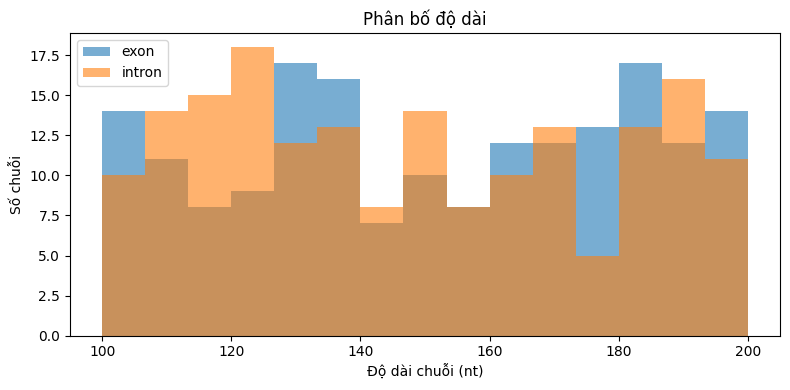

In [7]:
plt.figure(figsize=(8, 4))
plt.hist([len(x) for x in exon_sequences], bins=15, alpha=0.6, label="exon")
plt.hist([len(x) for x in intron_sequences], bins=15, alpha=0.6, label="intron")
plt.xlabel("Độ dài chuỗi (nt)")
plt.ylabel("Số chuỗi")
plt.title("Phân bố độ dài")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Chia train/validation/test

Với dữ liệu thật, hàm ưu tiên chia theo `gene_id` để các exon cùng gene không xuất hiện ở nhiều split. Với dữ liệu demo, mỗi chuỗi được gán một gene riêng nên cách chia tương đương chia theo sample.

In [8]:
def group_split_indices(
    metadata: pd.DataFrame,
    train_fraction: float = 0.60,
    validation_fraction: float = 0.20,
    seed: int = 42,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    groups = metadata["gene_id"].astype(str).unique()
    groups = rng.permutation(groups)
    n_train = int(train_fraction * len(groups))
    n_validation = int(validation_fraction * len(groups))

    train_groups = set(groups[:n_train])
    validation_groups = set(groups[n_train:n_train + n_validation])
    test_groups = set(groups[n_train + n_validation:])

    train_idx = metadata.index[metadata["gene_id"].astype(str).isin(train_groups)].to_numpy()
    validation_idx = metadata.index[metadata["gene_id"].astype(str).isin(validation_groups)].to_numpy()
    test_idx = metadata.index[metadata["gene_id"].astype(str).isin(test_groups)].to_numpy()
    return train_idx, validation_idx, test_idx


def apply_indices(sequences: Sequence[np.ndarray], indices: np.ndarray) -> list[np.ndarray]:
    return [sequences[int(index)] for index in indices]


exon_train_idx, exon_validation_idx, exon_test_idx = group_split_indices(exon_metadata, seed=SEED)
intron_train_idx, intron_validation_idx, intron_test_idx = group_split_indices(intron_metadata, seed=SEED)

exon_train = apply_indices(exon_sequences, exon_train_idx)
exon_validation = apply_indices(exon_sequences, exon_validation_idx)
exon_test = apply_indices(exon_sequences, exon_test_idx)

intron_train = apply_indices(intron_sequences, intron_train_idx)
intron_validation = apply_indices(intron_sequences, intron_validation_idx)
intron_test = apply_indices(intron_sequences, intron_test_idx)

shuffled_train = [shuffled_exon_sequences[i] for i in exon_train_idx]
shuffled_validation = [shuffled_exon_sequences[i] for i in exon_validation_idx]
shuffled_test = [shuffled_exon_sequences[i] for i in exon_test_idx]

pd.DataFrame({
    "dataset": ["exon", "intron", "shuffled exon"],
    "train": [len(exon_train), len(intron_train), len(shuffled_train)],
    "validation": [len(exon_validation), len(intron_validation), len(shuffled_validation)],
    "test": [len(exon_test), len(intron_test), len(shuffled_test)],
})

,dataset,train,validation,test
0,exon,108,36,36
1,intron,108,36,36
2,shuffled exon,108,36,36


## 10. Baseline không tuần hoàn

### IID baseline

Mỗi nucleotide độc lập với xác suất toàn cục $P(A),P(C),P(G),P(T)$.

### Markov bậc 1

Nucleotide tiếp theo phụ thuộc nucleotide trước:

$$P(x)=P(x_0)\prod_{t=1}^{T-1}P(x_t\mid x_{t-1}).$$

Hai baseline cho biết periodic HMM có mang thêm thông tin ngoài composition và phụ thuộc cục bộ hay không.

In [9]:
class IIDNucleotideModel:
    def __init__(self, pseudocount: float = 1.0):
        self.pseudocount = pseudocount

    def fit(self, sequences: Sequence[np.ndarray]) -> "IIDNucleotideModel":
        counts = np.bincount(np.concatenate(sequences), minlength=4).astype(float)
        counts += self.pseudocount
        self.probabilities_ = counts / counts.sum()
        return self

    def log_likelihood(self, sequence: np.ndarray) -> float:
        return float(np.log(self.probabilities_[sequence] + 1e-300).sum())

    def nll_per_token(self, sequences: Sequence[np.ndarray]) -> float:
        total_log_likelihood = sum(self.log_likelihood(sequence) for sequence in sequences)
        total_tokens = sum(len(sequence) for sequence in sequences)
        return -total_log_likelihood / total_tokens


class FirstOrderMarkovModel:
    def __init__(self, pseudocount: float = 1.0):
        self.pseudocount = pseudocount

    def fit(self, sequences: Sequence[np.ndarray]) -> "FirstOrderMarkovModel":
        initial_counts = np.full(4, self.pseudocount)
        transition_counts = np.full((4, 4), self.pseudocount)
        for sequence in sequences:
            initial_counts[sequence[0]] += 1
            np.add.at(transition_counts, (sequence[:-1], sequence[1:]), 1)
        self.initial_ = initial_counts / initial_counts.sum()
        self.transition_ = transition_counts / transition_counts.sum(axis=1, keepdims=True)
        return self

    def log_likelihood(self, sequence: np.ndarray) -> float:
        value = np.log(self.initial_[sequence[0]] + 1e-300)
        value += np.log(self.transition_[sequence[:-1], sequence[1:]] + 1e-300).sum()
        return float(value)

    def nll_per_token(self, sequences: Sequence[np.ndarray]) -> float:
        total_log_likelihood = sum(self.log_likelihood(sequence) for sequence in sequences)
        total_tokens = sum(len(sequence) for sequence in sequences)
        return -total_log_likelihood / total_tokens


iid_model = IIDNucleotideModel().fit(exon_train)
markov_model = FirstOrderMarkovModel().fit(exon_train)

baseline_df = pd.DataFrame({
    "model": ["IID", "Markov-1"],
    "validation_nll_per_nt": [
        iid_model.nll_per_token(exon_validation),
        markov_model.nll_per_token(exon_validation),
    ],
    "test_nll_per_nt": [
        iid_model.nll_per_token(exon_test),
        markov_model.nll_per_token(exon_test),
    ],
})
baseline_df.round(5)

,model,validation_nll_per_nt,test_nll_per_nt
0,IID,1.37018,1.36912
1,Markov-1,1.36213,1.36363


## 11. Cài đặt tied periodic HMM bằng EM

E-step tính posterior của pha bắt đầu $S$ cho từng chuỗi. M-step cập nhật:

$$\pi_s \propto \sum_i P(S_i=s\mid x_i),$$

và emission count tại mỗi pha được cộng có trọng số bởi posterior của tất cả pha bắt đầu có thể có.

`pseudocount` đóng vai trò Dirichlet regularization, tránh xác suất bằng 0.

In [10]:
class TiedPeriodicHMM:
    """Periodic categorical HMM with deterministic phase advance and unknown entry phase."""

    def __init__(self, period: int, seed: int = 42, pseudocount: float = 0.5):
        if period < 2:
            raise ValueError("period must be at least 2")
        self.period = period
        self.seed = seed
        self.pseudocount = pseudocount

    def _initialize(self, sequences: Sequence[np.ndarray]) -> None:
        rng = np.random.default_rng(self.seed)
        composition_counts = np.bincount(np.concatenate(sequences), minlength=4).astype(float) + 1.0
        composition = composition_counts / composition_counts.sum()
        self.emission_ = rng.dirichlet(50.0 * composition, size=self.period)
        self.entry_ = np.full(self.period, 1.0 / self.period)

    def _phase_posterior(self, sequence: np.ndarray) -> tuple[np.ndarray, float]:
        time = np.arange(len(sequence))
        states = (np.arange(self.period)[:, None] + time[None, :]) % self.period
        phase_scores = np.log(self.entry_ + 1e-300)
        phase_scores += np.log(self.emission_[states, sequence[None, :]] + 1e-300).sum(axis=1)
        log_likelihood = float(logsumexp(phase_scores))
        posterior = np.exp(phase_scores - log_likelihood)
        return posterior, log_likelihood

    def fit(
        self,
        sequences: Sequence[np.ndarray],
        max_iterations: int = 50,
        tolerance: float = 1e-5,
        verbose: bool = False,
    ) -> "TiedPeriodicHMM":
        if not sequences:
            raise ValueError("sequences must not be empty")
        self._initialize(sequences)
        self.history_ = []
        total_tokens = sum(len(sequence) for sequence in sequences)

        for iteration in range(max_iterations):
            emission_counts = np.full((self.period, 4), self.pseudocount)
            entry_counts = np.full(self.period, self.pseudocount)
            total_log_likelihood = 0.0

            for sequence in sequences:
                posterior, log_likelihood = self._phase_posterior(sequence)
                total_log_likelihood += log_likelihood
                entry_counts += posterior
                time = np.arange(len(sequence))

                for start_phase, weight in enumerate(posterior):
                    states = (start_phase + time) % self.period
                    np.add.at(emission_counts, (states, sequence), weight)

            self.entry_ = entry_counts / entry_counts.sum()
            self.emission_ = emission_counts / emission_counts.sum(axis=1, keepdims=True)

            nll = -total_log_likelihood / total_tokens
            self.history_.append(nll)
            if verbose:
                print(f"iteration={iteration:02d}, train NLL/nt={nll:.6f}")

            if iteration >= 2 and abs(self.history_[-2] - self.history_[-1]) < tolerance:
                break

        return self

    def log_likelihood(self, sequence: np.ndarray) -> float:
        return self._phase_posterior(sequence)[1]

    def nll_per_token(self, sequences: Sequence[np.ndarray]) -> float:
        total_log_likelihood = sum(self.log_likelihood(sequence) for sequence in sequences)
        total_tokens = sum(len(sequence) for sequence in sequences)
        return -total_log_likelihood / total_tokens

    def infer_start_phase(self, sequence: np.ndarray) -> tuple[int, np.ndarray]:
        posterior, _ = self._phase_posterior(sequence)
        return int(np.argmax(posterior)), posterior

## 12. Sanity check với chu kỳ 10

In [11]:
period_10_model = TiedPeriodicHMM(period=10, seed=SEED).fit(
    exon_train,
    max_iterations=50,
    tolerance=1e-6,
    verbose=True,
)

print("Validation NLL/nt:", round(period_10_model.nll_per_token(exon_validation), 6))
print("Test NLL/nt:", round(period_10_model.nll_per_token(exon_test), 6))

iteration=00, train NLL/nt=1.354117
iteration=01, train NLL/nt=1.256641
iteration=02, train NLL/nt=1.244309
iteration=03, train NLL/nt=1.244309
Validation NLL/nt: 1.243618
Test NLL/nt: 1.25269


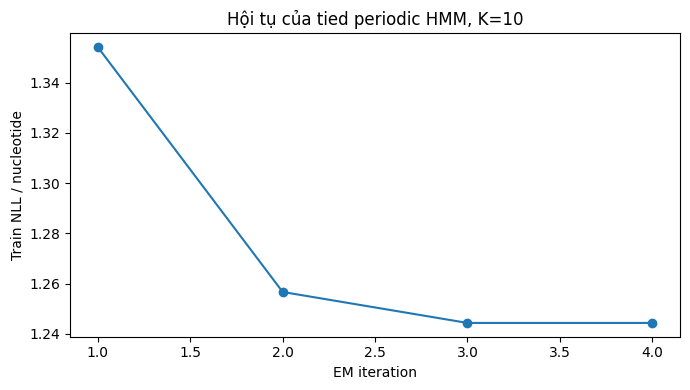

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, len(period_10_model.history_) + 1), period_10_model.history_, marker="o")
plt.xlabel("EM iteration")
plt.ylabel("Train NLL / nucleotide")
plt.title("Hội tụ của tied periodic HMM, K=10")
plt.tight_layout()
plt.show()

## 13. Model selection: quét chu kỳ 3–15

Mỗi period được huấn luyện nhiều lần với random initialization. Validation set chọn period; test set chỉ dùng để báo cáo cuối.

Metric chính:

$$\text{NLL/nt}=-\frac{\sum_i\log P(x_i)}{\sum_i|x_i|}.$$

**Càng thấp càng tốt.**

In [13]:
def scan_periods(
    train_sequences: Sequence[np.ndarray],
    validation_sequences: Sequence[np.ndarray],
    test_sequences: Sequence[np.ndarray],
    periods: Iterable[int] = range(3, 16),
    seeds: Sequence[int] = (11, 23, 47),
    max_iterations: int = 40,
) -> tuple[pd.DataFrame, dict[int, TiedPeriodicHMM]]:
    rows = []
    best_models: dict[int, TiedPeriodicHMM] = {}

    for period in periods:
        candidates = []
        for seed in seeds:
            model = TiedPeriodicHMM(period=period, seed=seed).fit(
                train_sequences,
                max_iterations=max_iterations,
                tolerance=1e-5,
            )
            candidates.append((model.nll_per_token(validation_sequences), model))

        validation_nll, best_model = min(candidates, key=lambda item: item[0])
        best_models[period] = best_model
        rows.append({
            "period": period,
            "validation_nll_per_nt": validation_nll,
            "test_nll_per_nt": best_model.nll_per_token(test_sequences),
            "iterations": len(best_model.history_),
        })

    return pd.DataFrame(rows), best_models


exon_period_scan, exon_period_models = scan_periods(
    exon_train,
    exon_validation,
    exon_test,
)

best_period_row = exon_period_scan.loc[exon_period_scan["validation_nll_per_nt"].idxmin()]
best_period = int(best_period_row["period"])
best_period_model = exon_period_models[best_period]

print("Best validation period:", best_period)
exon_period_scan.round(6)

Best validation period: 10


,period,validation_nll_per_nt,test_nll_per_nt,iterations
0,3,1.370434,1.369487,9
1,4,1.347312,1.346723,6
2,5,1.319115,1.325728,5
3,6,1.347940,1.347232,7
4,7,1.370311,1.370069,29
5,8,1.347530,1.346846,15
6,9,1.371390,1.370183,19
7,10,1.243618,1.252690,5
8,11,1.370464,1.369993,24
9,12,1.348489,1.347504,23


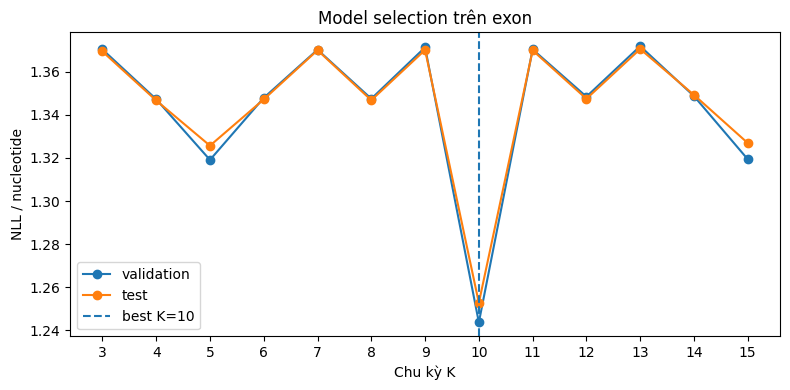

In [14]:
plt.figure(figsize=(8, 4))
plt.plot(exon_period_scan["period"], exon_period_scan["validation_nll_per_nt"], marker="o", label="validation")
plt.plot(exon_period_scan["period"], exon_period_scan["test_nll_per_nt"], marker="o", label="test")
plt.axvline(best_period, linestyle="--", label=f"best K={best_period}")
plt.xlabel("Chu kỳ K")
plt.ylabel("NLL / nucleotide")
plt.title("Model selection trên exon")
plt.xticks(exon_period_scan["period"])
plt.legend()
plt.tight_layout()
plt.show()

## 14. Control experiments: intron và shuffled exon

### Shuffled exon

Shuffle bên trong từng chuỗi bảo toàn:

- độ dài;
- số lượng A/C/G/T của từng chuỗi.

Nhưng shuffle phá vỡ thứ tự và periodicity. Nếu $K=10$ vẫn thắng mạnh sau shuffle, có khả năng pipeline đang học composition hoặc overfit.

### Deep intron/control

Intron được length-match và gần composition-match với exon. Tín hiệu periodicity được kỳ vọng yếu hơn.

In [15]:
intron_period_scan, _ = scan_periods(
    intron_train,
    intron_validation,
    intron_test,
    seeds=(11, 23),
    max_iterations=30,
)

shuffled_period_scan, _ = scan_periods(
    shuffled_train,
    shuffled_validation,
    shuffled_test,
    seeds=(11, 23),
    max_iterations=30,
)

comparison_scan = pd.concat([
    exon_period_scan.assign(dataset="exon"),
    intron_period_scan.assign(dataset="intron"),
    shuffled_period_scan.assign(dataset="shuffled_exon"),
], ignore_index=True)

comparison_scan.to_csv(OUTPUT_DIR / "period_scan.csv", index=False)
comparison_scan.head()

,period,validation_nll_per_nt,test_nll_per_nt,iterations,dataset
0,3,1.370434,1.369487,9,exon
1,4,1.347312,1.346723,6,exon
2,5,1.319115,1.325728,5,exon
3,6,1.347940,1.347232,7,exon
4,7,1.370311,1.370069,29,exon


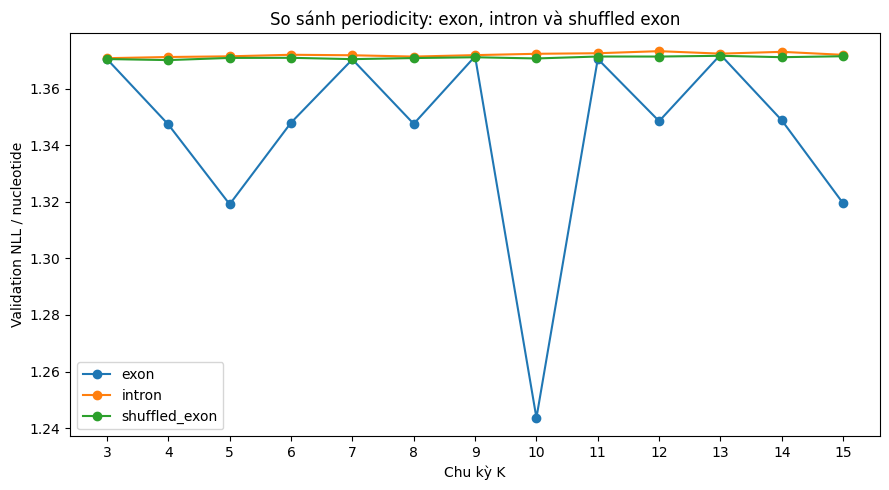

In [16]:
plt.figure(figsize=(9, 5))
for dataset, group in comparison_scan.groupby("dataset"):
    plt.plot(group["period"], group["validation_nll_per_nt"], marker="o", label=dataset)
plt.xlabel("Chu kỳ K")
plt.ylabel("Validation NLL / nucleotide")
plt.title("So sánh periodicity: exon, intron và shuffled exon")
plt.xticks(sorted(comparison_scan["period"].unique()))
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
def best_period_summary(scan: pd.DataFrame, dataset: str) -> dict[str, float | int | str]:
    row = scan.loc[scan["validation_nll_per_nt"].idxmin()]
    return {
        "dataset": dataset,
        "best_period": int(row["period"]),
        "validation_nll_per_nt": row["validation_nll_per_nt"],
        "test_nll_per_nt": row["test_nll_per_nt"],
    }

best_periods_df = pd.DataFrame([
    best_period_summary(exon_period_scan, "exon"),
    best_period_summary(intron_period_scan, "intron"),
    best_period_summary(shuffled_period_scan, "shuffled_exon"),
])
best_periods_df.round(6)

,dataset,best_period,validation_nll_per_nt,test_nll_per_nt
0,exon,10,1.243618,1.252690
1,intron,3,1.370741,1.368861
2,shuffled_exon,4,1.370066,1.369277


## 15. So sánh với baseline

So sánh IID, Markov-1 và periodic HMM trên cùng test exon. Nếu periodic HMM có NLL thấp hơn, mô hình tuần hoàn giải thích dữ liệu tốt hơn composition và phụ thuộc một bước.

In [18]:
model_comparison_df = pd.DataFrame({
    "model": ["IID", "Markov-1", f"Tied periodic HMM (K={best_period})"],
    "test_nll_per_nt": [
        iid_model.nll_per_token(exon_test),
        markov_model.nll_per_token(exon_test),
        best_period_model.nll_per_token(exon_test),
    ],
})
model_comparison_df["delta_vs_iid"] = (
    model_comparison_df["test_nll_per_nt"] - model_comparison_df.loc[0, "test_nll_per_nt"]
)
model_comparison_df.round(6)

,model,test_nll_per_nt,delta_vs_iid
0,IID,1.369122,0.000000
1,Markov-1,1.363633,-0.005489
2,Tied periodic HMM (K=10),1.252690,-0.116432


## 16. Bootstrap khoảng tin cậy cho chênh lệch NLL

Ta bootstrap theo **chuỗi**, không bootstrap từng nucleotide, vì nucleotide trong cùng chuỗi không độc lập.

Giá trị kiểm tra:

$$\Delta=\text{NLL}_{K=10}-\text{NLL}_{K=9}.$$

Nếu khoảng tin cậy của $\Delta$ nằm dưới 0, period 10 tốt hơn period 9 trên held-out sequences.

In [19]:
def sequence_nlls(model, sequences: Sequence[np.ndarray]) -> np.ndarray:
    return np.array([-model.log_likelihood(sequence) / len(sequence) for sequence in sequences])


def bootstrap_mean_difference(
    values_a: np.ndarray,
    values_b: np.ndarray,
    n_bootstrap: int = 2000,
    seed: int = 42,
) -> tuple[float, float, float]:
    if len(values_a) != len(values_b):
        raise ValueError("Paired bootstrap requires equal lengths")
    rng = np.random.default_rng(seed)
    differences = np.empty(n_bootstrap)
    n = len(values_a)
    for iteration in range(n_bootstrap):
        indices = rng.integers(0, n, size=n)
        differences[iteration] = (values_a[indices] - values_b[indices]).mean()
    estimate = (values_a - values_b).mean()
    lower, upper = np.quantile(differences, [0.025, 0.975])
    return float(estimate), float(lower), float(upper)


period_a = best_period
period_b = 9 if best_period != 9 else 10
model_a = exon_period_models[period_a]
model_b = exon_period_models[period_b]

a_nll = sequence_nlls(model_a, exon_test)
b_nll = sequence_nlls(model_b, exon_test)
estimate, lower, upper = bootstrap_mean_difference(a_nll, b_nll)

bootstrap_df = pd.DataFrame([{
    "comparison": f"K={period_a} minus K={period_b}",
    "mean_delta_nll_per_nt": estimate,
    "ci_2.5%": lower,
    "ci_97.5%": upper,
}])
bootstrap_df.round(6)

,comparison,mean_delta_nll_per_nt,ci_2.5%,ci_97.5%
0,K=10 minus K=9,-0.116818,-0.126471,-0.106308


## 17. Phân tích emission profile

Mỗi hàng là một pha trong chu kỳ, mỗi cột là A/C/G/T. Các pha có entropy thấp chứa motif đặc hiệu hơn.

Entropy:

$$H(k)=-\sum_b B_{k,b}\log_2B_{k,b}.$$

In [20]:
def emission_entropy(emission: np.ndarray) -> np.ndarray:
    return -(emission * np.log2(emission + 1e-300)).sum(axis=1)


def consensus_from_emission(emission: np.ndarray, threshold: float = 0.35) -> list[str]:
    consensus = []
    for probabilities in emission:
        selected = ALPHABET[probabilities >= threshold]
        if len(selected) == 0:
            selected = np.array([ALPHABET[np.argmax(probabilities)]])
        consensus.append(selected[0] if len(selected) == 1 else "[" + "".join(selected) + "]")
    return consensus


emission_df = pd.DataFrame(best_period_model.emission_, columns=ALPHABET)
emission_df.index.name = "phase"
emission_df["entropy_bits"] = emission_entropy(best_period_model.emission_)
emission_df["consensus"] = consensus_from_emission(best_period_model.emission_)
emission_df.to_csv(OUTPUT_DIR / "best_period_emissions.csv")

print("Consensus theo từng pha:", " ".join(emission_df["consensus"]))
emission_df.round(4)

Consensus theo từng pha: T A A A A A [AT] G T T


,A,C,G,T,entropy_bits,consensus
phase,,,,,,
0,0.2548,0.2542,0.2094,0.2817,1.9921,T
1,0.2945,0.2038,0.2455,0.2563,1.9878,A
2,0.3253,0.1589,0.2840,0.2319,1.9534,A
3,0.3392,0.1440,0.2805,0.2362,1.9379,A
4,0.3352,0.1702,0.2602,0.2344,1.9593,A
5,0.3620,0.2540,0.3266,0.0573,1.7965,A
6,0.4745,0.0556,0.0394,0.4306,1.4492,[AT]
7,0.0482,0.0452,0.8691,0.0374,0.7664,G
8,0.2015,0.2835,0.1614,0.3536,1.9363,T


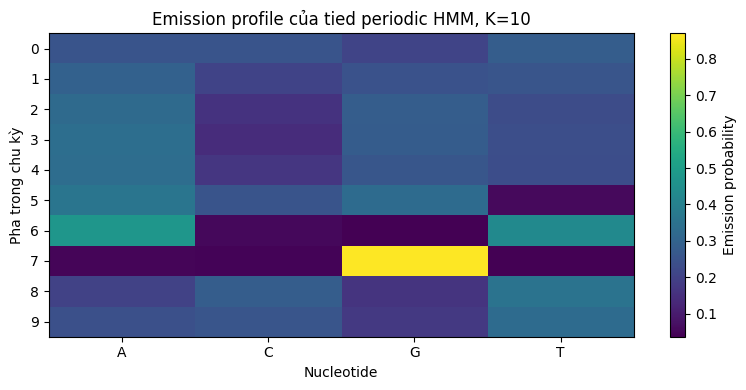

In [21]:
plt.figure(figsize=(8, max(4, 0.35 * best_period)))
image = plt.imshow(best_period_model.emission_, aspect="auto")
plt.colorbar(image, label="Emission probability")
plt.xticks(np.arange(4), ALPHABET)
plt.yticks(np.arange(best_period), np.arange(best_period))
plt.xlabel("Nucleotide")
plt.ylabel("Pha trong chu kỳ")
plt.title(f"Emission profile của tied periodic HMM, K={best_period}")
plt.tight_layout()
plt.show()

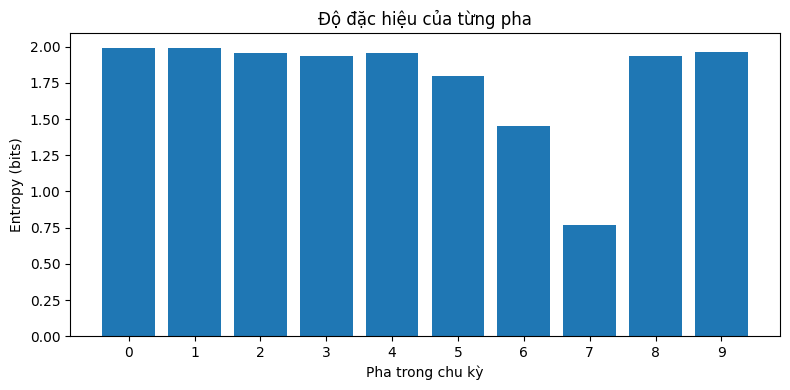

In [22]:
plt.figure(figsize=(8, 4))
plt.bar(np.arange(best_period), emission_entropy(best_period_model.emission_))
plt.xlabel("Pha trong chu kỳ")
plt.ylabel("Entropy (bits)")
plt.title("Độ đặc hiệu của từng pha")
plt.xticks(np.arange(best_period))
plt.tight_layout()
plt.show()

### Căn chỉnh pha posterior

HMM không cần các chuỗi bắt đầu ở cùng pha. Với mỗi sequence, posterior $P(S=s\mid x)$ xác định pha bắt đầu phù hợp nhất. Sau khi suy luận pha, ta có thể căn chỉnh chuỗi theo wheel state thay vì theo nucleotide position tuyệt đối.

In [23]:
phase_rows = []
for index, sequence in enumerate(exon_test[:10]):
    inferred_phase, posterior = best_period_model.infer_start_phase(sequence)
    phase_rows.append({
        "sequence_index": index,
        "length": len(sequence),
        "inferred_start_phase": inferred_phase,
        "posterior_max": posterior.max(),
        "first_30_nt": decode_sequence(sequence[:30]),
    })

pd.DataFrame(phase_rows).round(4)

,sequence_index,length,inferred_start_phase,posterior_max,first_30_nt
0,0,153,6,1.0,TGGTTCGATCAGTCGATAAGTGCTTCGGGG
1,1,155,7,1.0,GCTTTTAGATGCTAGGAGGAGCGATTAACT
2,2,131,1,1.0,ACGTCTCAATAGATGAAATAGCTCCTGTAC
3,3,118,5,1.0,GTGGCCTGGCAAGCTGAAATCTGAGTCATT
4,4,102,2,1.0,TATATGCAAATTTATGGCCGACGATGTGTG
5,5,108,5,1.0,CAGTCGCTAACTGGTCAAACCAGCTGCCGG
6,6,104,3,1.0,CTATGCTGGAATGTGATCTAAGGTGCTCCG
7,7,118,6,1.0,TGGTATAGTGTGTGGAAGAGTGATACTAAA
8,8,154,4,1.0,AAAGTTCGGTAAACCTTACCCCAGTGGGCA
9,9,185,6,1.0,TGCCCGCAGGTGCATGGTAGAGCCTCTGGG


## 18. Flexible wheel HMM

Tied model ở trên buộc pha luôn tăng đúng một bước. Flexible wheel HMM gần tinh thần wheel/loop architecture hơn:

- self-transition hấp thụ một nucleotide insert;
- advance là đường backbone;
- skip bỏ qua một phase;
- mọi state đều có emission distribution riêng;
- entry distribution cho phép bắt đầu tại bất kỳ state nào.

Model được huấn luyện bằng Baum–Welch. Vì forward–backward tốn hơn, notebook chỉ so sánh các period gần ứng viên tốt nhất.

In [24]:
class FlexibleWheelHMM:
    """Categorical wheel HMM with stay, advance and skip transitions."""

    def __init__(
        self,
        period: int,
        seed: int = 42,
        pseudocount: float = 0.1,
        allow_self: bool = True,
        allow_skip: bool = True,
    ):
        self.period = period
        self.seed = seed
        self.pseudocount = pseudocount
        self.transition_mask = np.zeros((period, period), dtype=bool)
        for state in range(period):
            self.transition_mask[state, (state + 1) % period] = True
            if allow_self:
                self.transition_mask[state, state] = True
            if allow_skip:
                self.transition_mask[state, (state + 2) % period] = True

    def _initialize(self, sequences: Sequence[np.ndarray]) -> None:
        rng = np.random.default_rng(self.seed)
        composition_counts = np.bincount(np.concatenate(sequences), minlength=4).astype(float) + 1.0
        composition = composition_counts / composition_counts.sum()
        self.emission_ = rng.dirichlet(50.0 * composition, size=self.period)
        self.entry_ = np.full(self.period, 1.0 / self.period)

        self.transition_ = np.zeros((self.period, self.period))
        for state in range(self.period):
            allowed = np.flatnonzero(self.transition_mask[state])
            weights = np.full(len(allowed), 0.05)
            for index, destination in enumerate(allowed):
                if destination == (state + 1) % self.period:
                    weights[index] = 0.90
            weights /= weights.sum()
            self.transition_[state, allowed] = weights

    def _forward_backward(self, sequence: np.ndarray):
        length = len(sequence)
        log_transition = np.full((self.period, self.period), -np.inf)
        log_transition[self.transition_mask] = np.log(
            self.transition_[self.transition_mask] + 1e-300
        )
        log_emission = np.log(self.emission_ + 1e-300)

        log_alpha = np.empty((length, self.period))
        log_beta = np.empty((length, self.period))

        log_alpha[0] = np.log(self.entry_ + 1e-300) + log_emission[:, sequence[0]]
        for position in range(1, length):
            log_alpha[position] = log_emission[:, sequence[position]] + logsumexp(
                log_alpha[position - 1][:, None] + log_transition,
                axis=0,
            )

        log_likelihood = float(logsumexp(log_alpha[-1]))
        log_beta[-1] = 0.0
        for position in range(length - 2, -1, -1):
            log_beta[position] = logsumexp(
                log_transition
                + log_emission[:, sequence[position + 1]][None, :]
                + log_beta[position + 1][None, :],
                axis=1,
            )

        return log_alpha, log_beta, log_likelihood, log_transition, log_emission

    def fit(
        self,
        sequences: Sequence[np.ndarray],
        max_iterations: int = 15,
        tolerance: float = 1e-4,
        verbose: bool = False,
    ) -> "FlexibleWheelHMM":
        self._initialize(sequences)
        self.history_ = []
        total_tokens = sum(len(sequence) for sequence in sequences)

        for iteration in range(max_iterations):
            entry_counts = np.full(self.period, self.pseudocount)
            transition_counts = np.zeros((self.period, self.period))
            transition_counts[self.transition_mask] = self.pseudocount
            emission_counts = np.full((self.period, 4), self.pseudocount)
            total_log_likelihood = 0.0

            for sequence in sequences:
                log_alpha, log_beta, log_likelihood, log_transition, log_emission = (
                    self._forward_backward(sequence)
                )
                total_log_likelihood += log_likelihood
                gamma = np.exp(log_alpha + log_beta - log_likelihood)
                entry_counts += gamma[0]

                for nucleotide in range(4):
                    emission_counts[:, nucleotide] += gamma[sequence == nucleotide].sum(axis=0)

                # Vectorized expected transition counts for all positions.
                log_xi_all = (
                    log_alpha[:-1, :, None]
                    + log_transition[None, :, :]
                    + log_emission[:, sequence[1:]].T[:, None, :]
                    + log_beta[1:, None, :]
                    - log_likelihood
                )
                xi_sum = np.exp(log_xi_all).sum(axis=0)
                transition_counts[self.transition_mask] += xi_sum[self.transition_mask]

            self.entry_ = entry_counts / entry_counts.sum()
            self.transition_ = np.divide(
                transition_counts,
                transition_counts.sum(axis=1, keepdims=True),
                out=np.zeros_like(transition_counts),
                where=transition_counts.sum(axis=1, keepdims=True) > 0,
            )
            self.emission_ = emission_counts / emission_counts.sum(axis=1, keepdims=True)

            nll = -total_log_likelihood / total_tokens
            self.history_.append(nll)
            if verbose:
                print(f"iteration={iteration:02d}, train NLL/nt={nll:.6f}")
            if iteration >= 2 and abs(self.history_[-2] - self.history_[-1]) < tolerance:
                break

        return self

    def log_likelihood(self, sequence: np.ndarray) -> float:
        return self._forward_backward(sequence)[2]

    def nll_per_token(self, sequences: Sequence[np.ndarray]) -> float:
        total_log_likelihood = sum(self.log_likelihood(sequence) for sequence in sequences)
        total_tokens = sum(len(sequence) for sequence in sequences)
        return -total_log_likelihood / total_tokens

### Huấn luyện wheel HMM quanh period tốt nhất

Để notebook chạy nhanh, dùng tối đa 8 chuỗi train trong bản demo đã thực thi. Khi chạy dữ liệu thật, tăng lên 100–500 chuỗi (và chấp nhận thời gian chạy dài hơn) và chạy nhiều seed.

In [25]:
wheel_candidate_periods = sorted(set([
    max(3, best_period - 1),
    best_period,
    best_period + 1,
]))
wheel_train_subset = exon_train[: min(8, len(exon_train))]
wheel_validation_subset = exon_validation[: min(4, len(exon_validation))]
wheel_test_subset = exon_test[: min(4, len(exon_test))]

wheel_rows = []
wheel_models = {}
for period in wheel_candidate_periods:
    model = FlexibleWheelHMM(period=period, seed=SEED).fit(
        wheel_train_subset,
        max_iterations=4,
        tolerance=1e-4,
        verbose=False,
    )
    wheel_models[period] = model
    wheel_rows.append({
        "period": period,
        "validation_nll_per_nt": model.nll_per_token(wheel_validation_subset),
        "test_nll_per_nt": model.nll_per_token(wheel_test_subset),
        "iterations": len(model.history_),
    })

wheel_df = pd.DataFrame(wheel_rows)
wheel_df.round(6)

,period,validation_nll_per_nt,test_nll_per_nt,iterations
0,9,1.381893,1.372969,4
1,10,1.290244,1.294573,4
2,11,1.379738,1.371470,4


In [26]:
best_wheel_period = int(wheel_df.loc[wheel_df["validation_nll_per_nt"].idxmin(), "period"])
best_wheel_model = wheel_models[best_wheel_period]

transition_rows = []
for state in range(best_wheel_period):
    transition_rows.append({
        "state": state,
        "stay": best_wheel_model.transition_[state, state],
        "advance": best_wheel_model.transition_[state, (state + 1) % best_wheel_period],
        "skip": best_wheel_model.transition_[state, (state + 2) % best_wheel_period],
    })
transition_df = pd.DataFrame(transition_rows)
transition_df.round(4)

,state,stay,advance,skip
0,0,0.0156,0.9645,0.0200
1,1,0.0154,0.9648,0.0198
2,2,0.0151,0.9660,0.0189
3,3,0.0148,0.9653,0.0199
4,4,0.0142,0.9672,0.0185
5,5,0.0152,0.9660,0.0188
6,6,0.0149,0.9670,0.0181
7,7,0.0154,0.9701,0.0146
8,8,0.0169,0.9727,0.0103
9,9,0.0189,0.9620,0.0191


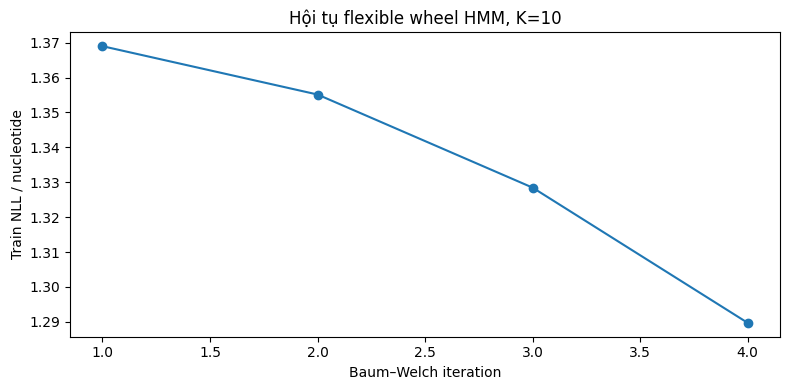

In [27]:
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(best_wheel_model.history_) + 1), best_wheel_model.history_, marker="o")
plt.xlabel("Baum–Welch iteration")
plt.ylabel("Train NLL / nucleotide")
plt.title(f"Hội tụ flexible wheel HMM, K={best_wheel_period}")
plt.tight_layout()
plt.show()

## 19. Autocorrelation như một baseline ngoài HMM

Autocorrelation không thay thế HMM, nhưng giúp kiểm tra độc lập xem các nucleotide indicator có tương quan tại lag 3, 9, 10 hoặc 11 hay không.

Ta one-hot encode A/C/G/T, tính tương quan của cùng nucleotide sau một khoảng lag và trung bình trên các chuỗi.

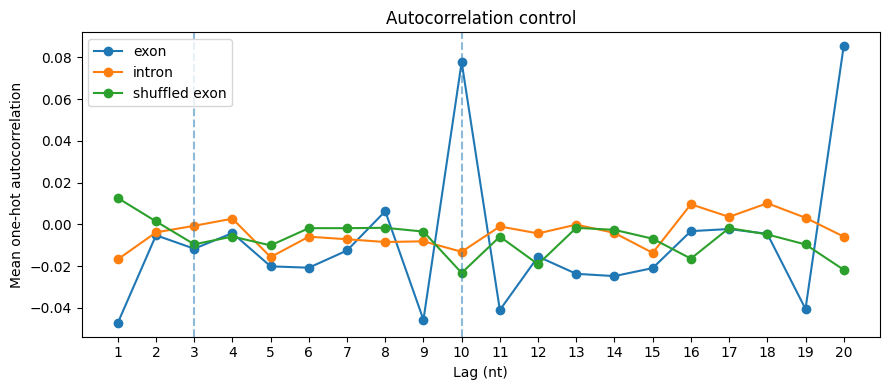

In [28]:
def mean_onehot_autocorrelation(
    sequences: Sequence[np.ndarray],
    max_lag: int = 20,
) -> np.ndarray:
    values = np.zeros(max_lag + 1)
    weights = np.zeros(max_lag + 1)

    for sequence in sequences:
        onehot = np.eye(4)[sequence]
        centered = onehot - onehot.mean(axis=0, keepdims=True)
        for lag in range(1, min(max_lag, len(sequence) - 1) + 1):
            numerator = (centered[:-lag] * centered[lag:]).sum()
            denominator = np.sqrt(
                (centered[:-lag] ** 2).sum() * (centered[lag:] ** 2).sum()
            )
            if denominator > 0:
                values[lag] += numerator / denominator
                weights[lag] += 1

    return np.divide(values, weights, out=np.zeros_like(values), where=weights > 0)


max_lag = 20
exon_ac = mean_onehot_autocorrelation(exon_test, max_lag=max_lag)
intron_ac = mean_onehot_autocorrelation(intron_test, max_lag=max_lag)
shuffle_ac = mean_onehot_autocorrelation(shuffled_test, max_lag=max_lag)

plt.figure(figsize=(9, 4))
lags = np.arange(1, max_lag + 1)
plt.plot(lags, exon_ac[1:], marker="o", label="exon")
plt.plot(lags, intron_ac[1:], marker="o", label="intron")
plt.plot(lags, shuffle_ac[1:], marker="o", label="shuffled exon")
plt.axvline(3, linestyle="--", alpha=0.5)
plt.axvline(10, linestyle="--", alpha=0.5)
plt.xlabel("Lag (nt)")
plt.ylabel("Mean one-hot autocorrelation")
plt.title("Autocorrelation control")
plt.xticks(lags)
plt.legend()
plt.tight_layout()
plt.show()

## 20. Tự động diễn giải kết quả

Các tiêu chí nên được đọc cùng nhau:

1. period được chọn trên validation;
2. test NLL thấp hơn baseline;
3. exon tốt hơn shuffled exon tại period ứng viên;
4. emission có các pha entropy thấp và motif có thể diễn giải;
5. bootstrap cho thấy lợi thế ổn định;
6. flexible wheel không cần dùng stay/skip quá mạnh để giả tạo chu kỳ.

In [29]:
exon_best = best_period_summary(exon_period_scan, "exon")
intron_best = best_period_summary(intron_period_scan, "intron")
shuffle_best = best_period_summary(shuffled_period_scan, "shuffled_exon")

print("KẾT LUẬN TỰ ĐỘNG")
print("- Best exon period:", exon_best["best_period"])
print("- Best intron period:", intron_best["best_period"])
print("- Best shuffled-exon period:", shuffle_best["best_period"])
print(
    "- Periodic HMM improvement vs IID on exon test:",
    round(iid_model.nll_per_token(exon_test) - best_period_model.nll_per_token(exon_test), 6),
    "NLL/nt",
)
print(
    f"- Bootstrap delta K={period_a} minus K={period_b}: "
    f"{estimate:.6f}, 95% CI [{lower:.6f}, {upper:.6f}]"
)

if not USE_REAL_DATA and best_period == 10:
    print("- Sanity check đạt: mô hình khôi phục đúng chu kỳ 10 đã cài trong dữ liệu mô phỏng.")
elif not USE_REAL_DATA:
    print("- Sanity check chưa đạt: tăng số chuỗi, số lần khởi tạo hoặc kiểm tra implementation.")
else:
    print("- Đây là kết quả trên dữ liệu thật; cần chạy nhiều seed và kiểm tra robustness trước khi kết luận sinh học.")

KẾT LUẬN TỰ ĐỘNG
- Best exon period: 10
- Best intron period: 3
- Best shuffled-exon period: 4
- Periodic HMM improvement vs IID on exon test: 0.116432 NLL/nt
- Bootstrap delta K=10 minus K=9: -0.116818, 95% CI [-0.126471, -0.106308]
- Sanity check đạt: mô hình khôi phục đúng chu kỳ 10 đã cài trong dữ liệu mô phỏng.


## 21. Ablation và thí nghiệm cần chạy khi dùng dữ liệu thật

### Bắt buộc

1. **Nhiều random seeds:** ít nhất 5 seed cho mỗi $K$.
2. **Split theo chromosome:** ví dụ train chr1–16, validation chr17–19, test chr20–22; hoặc group split theo gene.
3. **Exon phase control:** chia exon theo CDS phase 0/1/2 rồi chạy riêng.
4. **Dinucleotide shuffle:** shuffle nhưng bảo toàn gần đúng dinucleotide count, mạnh hơn nucleotide shuffle.
5. **GC-matched intron:** ghép mỗi exon với deep intron có GC và chiều dài gần nhất.
6. **Period grid rộng hơn:** $K=2\ldots 20$.
7. **Complexity penalty:** báo cáo AIC/BIC hoặc held-out NLL vì model có $4K$ emission parameters.
8. **Bootstrap theo gene:** không bootstrap từng exon nếu một gene đóng góp nhiều exon.

### Nên có

- so sánh standard left–right profile HMM;
- wheel chỉ advance, wheel + stay, wheel + stay + skip;
- regularization strength ablation;
- Fourier/power spectrum baseline;
- kiểm tra motif có giữ nguyên trên các chromosome và tập gene khác nhau hay không.

## 22. Lưu kết quả

Notebook đã lưu:

- `outputs_hmm_periodicity/period_scan.csv`;
- `outputs_hmm_periodicity/best_period_emissions.csv`.

Có thể bổ sung lưu model bằng `pickle`, nhưng khi nghiên cứu nên lưu cả:

- config;
- GENCODE release;
- checksum của GTF/FASTA;
- random seed;
- IDs của train/validation/test;
- phiên bản code và thư viện.

In [30]:
model_comparison_df.to_csv(OUTPUT_DIR / "model_comparison.csv", index=False)
best_periods_df.to_csv(OUTPUT_DIR / "best_period_summary.csv", index=False)
bootstrap_df.to_csv(OUTPUT_DIR / "bootstrap_period_comparison.csv", index=False)
wheel_df.to_csv(OUTPUT_DIR / "wheel_model_comparison.csv", index=False)
transition_df.to_csv(OUTPUT_DIR / "best_wheel_transitions.csv", index=False)

print("Các file kết quả:")
for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path)

Các file kết quả:
- outputs_hmm_periodicity/best_period_emissions.csv
- outputs_hmm_periodicity/best_period_summary.csv
- outputs_hmm_periodicity/best_wheel_transitions.csv
- outputs_hmm_periodicity/bootstrap_period_comparison.csv
- outputs_hmm_periodicity/model_comparison.csv
- outputs_hmm_periodicity/period_scan.csv
- outputs_hmm_periodicity/wheel_model_comparison.csv


## 23. Cách đọc kết quả khi chuyển sang GENCODE

Không nên kết luận “exon có chu kỳ 10” chỉ vì đường $K=10$ thấp nhất một lần. Kết luận mạnh cần đồng thời có:

- $K=10$ hoặc vùng gần 10 thắng ổn định qua seed và split;
- lợi thế held-out NLL có confidence interval rõ;
- shuffled và dinucleotide-shuffled controls mất tín hiệu;
- deep intron yếu hơn exon hoặc có profile khác;
- kết quả không biến mất khi kiểm soát CDS phase/codon usage;
- motif emission tương tự giữa các fold thay vì đổi hoàn toàn theo initialization.

Nếu chỉ thấy $K=3$ thắng, đó có thể chủ yếu là reading-frame/codon signal. Nếu mọi $K$ gần như ngang nhau, dữ liệu hoặc mô hình không cung cấp bằng chứng đủ mạnh về periodicity.

## 24. Tài liệu tham khảo

1. P. Baldi và S. Brunak, *Bioinformatics: The Machine Learning Approach*, 2nd ed., MIT Press, 2001, mục 8.2.3, trang 212–219 trong trích đoạn được cung cấp.
2. P. Baldi, S. Brunak, Y. Chauvin, J. Engelbrecht và A. Krogh, “Periodic Sequence Patterns in Human Exons,” *Proceedings of ISMB*, 1995, pp. 30–38. PMID: 7584451.
3. GENCODE Human Release 50, GRCh38.p14, June 2026.

### Ghi chú phương pháp

Tied periodic HMM trong notebook là một phiên bản tối giản và minh bạch của wheel model: state tiến xác định, chỉ pha bắt đầu là ẩn. Flexible wheel HMM bổ sung stay/skip để gần hơn với logic insert/delete. Notebook không tuyên bố sao chép chính xác implementation gradient-descent và regularizer của tác giả năm 1995.